# Language Model Foundations

First inspect a fixed-window predictor on a repeated string. Then train a character GRU on distinct local sentences, select with validation loss, compare held-out character perplexity against unigram/bigram baselines, and generate bounded continuations.

In [1]:
import torch
from torch import nn

torch.manual_seed(41)
torch.set_num_threads(1)
print('CPU | character next-token example')

CPU | character next-token example


In [2]:
text = 'deep learning ' * 20
alphabet = sorted(set(text))
to_id = {character: index for index, character in enumerate(alphabet)}
tokens = torch.tensor([to_id[character] for character in text])
context = 8
inputs = torch.stack([tokens[index:index+context] for index in range(len(tokens)-context)])
targets = torch.stack([tokens[index+1:index+context+1] for index in range(len(tokens)-context)])
assert inputs.shape == targets.shape and inputs.shape[1] == context
print('vocabulary:', ''.join(alphabet), '| examples:', len(inputs), '| context:', context)

vocabulary:  adegilnpr | examples: 272 | context: 8


In [3]:
model = nn.Sequential(nn.Embedding(len(alphabet), 16), nn.Flatten(),
                      nn.Linear(context * 16, len(alphabet)))
optimizer = torch.optim.Adam(model.parameters(), lr=0.02)
for _ in range(100):
    selection = torch.randint(len(inputs), (32,))
    logits = model(inputs[selection])
    loss = nn.functional.cross_entropy(logits, targets[selection, -1])
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
assert torch.isfinite(loss)
print(f'next-character loss={loss.item():.4f}')
print('predicted next character:', alphabet[model(inputs[:1]).argmax(1).item()])

next-character loss=0.0000
predicted next character: r


The repeated training string lets this small model memorize its patterns, which is why its training loss can approach zero. There is no held-out text here; this result does not measure generalization or language understanding.

## Complete project: character language modeling on excluded sentences

The first example isolates eight-character window mechanics on a repeated phrase. This second model trains on 192 unique synthetic sentences, chooses a checkpoint with 32 validation sentences, and evaluates on 32 excluded sentences. We split documents before encoding; no windows cross sentence boundaries. It uses a GRU so the lesson can focus on tokenization, shifted targets, likelihood, and generation rather than repeat the Transformer implementation in lesson 32.

The corpus combines four colors, animals, actions, and places. Held-out sentences contain new combinations of familiar pieces, not unrelated natural language. The random choice of those pieces makes some next characters intrinsically uncertain. Training vocabulary includes explicit PAD, BOS, EOS, and UNK symbols; only PAD targets are ignored in loss.

In [4]:
import itertools, math, copy
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')
import matplotlib.pyplot as plt
import torch.nn.functional as F

torch.manual_seed(410)
char_documents = ['the {} {} {} near the {}.'.format(*items)
                  for items in itertools.product(['blue', 'green', 'red', 'yellow'],
                                                 ['bird', 'cat', 'dog', 'fox'],
                                                 ['rests', 'runs', 'sits', 'walks'],
                                                 ['garden', 'hill', 'pond', 'tree'])]
char_split_rng = torch.Generator().manual_seed(410)
char_order = torch.randperm(len(char_documents), generator=char_split_rng).tolist()
char_train_docs = [char_documents[i] for i in char_order[:192]]
char_valid_docs = [char_documents[i] for i in char_order[192:224]]
char_test_docs = [char_documents[i] for i in char_order[224:]]
assert not (set(char_train_docs) & set(char_valid_docs) or set(char_train_docs) & set(char_test_docs)
            or set(char_valid_docs) & set(char_test_docs))
char_vocabulary = ['<pad>', '<bos>', '<eos>', '<unk>'] + sorted(set(''.join(char_train_docs)))
char_to_id = {character: index for index, character in enumerate(char_vocabulary)}
CHAR_PAD, CHAR_BOS, CHAR_EOS, CHAR_UNK = range(4)

def encode_char_documents(documents):
    sequences = [torch.tensor([CHAR_BOS] + [char_to_id.get(c, CHAR_UNK) for c in text] + [CHAR_EOS])
                 for text in documents]
    return nn.utils.rnn.pad_sequence(sequences, batch_first=True, padding_value=CHAR_PAD)

char_train_tokens, char_valid_tokens, char_test_tokens = map(encode_char_documents,
    [char_train_docs, char_valid_docs, char_test_docs])
assert (char_valid_tokens != CHAR_UNK).all() and (char_test_tokens != CHAR_UNK).all()
print('sentences:', len(char_train_docs), len(char_valid_docs), len(char_test_docs))
print('character vocabulary:', len(char_vocabulary), '| padded training shape:', tuple(char_train_tokens.shape))
print('first sentence:', char_train_docs[0])

sentences: 192 32 32
character vocabulary: 27 | padded training shape: (192, 40)
first sentence: the red dog walks near the pond.


### Predict every valid shifted target

Each input row starts with BOS and contains earlier characters; each target row is shifted one position ahead. Unlike the first fixed-window head, this GRU emits one distribution **at every position**. Right padding follows EOS and is excluded from the objective. Recurrence is unidirectional, so padding after the true sequence cannot alter its earlier predictions. Every document begins with a fresh hidden state.

In [5]:
class CharacterLanguageModel(nn.Module):
    def __init__(self, vocabulary_size):
        super().__init__()
        self.embedding = nn.Embedding(vocabulary_size, 24, padding_idx=CHAR_PAD)
        self.recurrent = nn.GRU(24, 64, batch_first=True)
        self.head = nn.Linear(64, vocabulary_size)
    def forward(self, ids, hidden=None):
        states, hidden = self.recurrent(self.embedding(ids), hidden)
        return self.head(states), hidden

char_lm = CharacterLanguageModel(len(char_vocabulary))
probe_ids = char_train_tokens[:2, :-1]
probe_logits, _ = char_lm(probe_ids)
assert probe_logits.shape == (*probe_ids.shape, len(char_vocabulary))
# Valid predictions are unchanged by appending extra right padding.
char_lm.eval()
with torch.no_grad():
    single = encode_char_documents([char_train_docs[0]])[:, :-1]
    padded = F.pad(single, (0, 4), value=CHAR_PAD)
    torch.testing.assert_close(char_lm(single)[0], char_lm(padded)[0][:, :single.shape[1]],
                               rtol=1e-5, atol=1e-6)
print('parameters:', sum(p.numel() for p in char_lm.parameters()), '| padding invariance passed')

parameters: 19683 | padding invariance passed


In [6]:
@torch.no_grad()
def evaluate_characters(model, encoded_documents):
    model.eval()
    total_nll, total_correct, total_tokens = 0.0, 0, 0
    for rows in encoded_documents.split(32):
        logits, _ = model(rows[:, :-1])
        labels = rows[:, 1:]
        valid = labels.ne(CHAR_PAD)
        total_nll += F.cross_entropy(logits.reshape(-1, len(char_vocabulary)), labels.reshape(-1),
                                     ignore_index=CHAR_PAD, reduction='sum').item()
        total_correct += (logits.argmax(-1)[valid] == labels[valid]).sum().item()
        total_tokens += valid.sum().item()
    return total_nll / total_tokens, total_correct / total_tokens

char_optimizer = torch.optim.Adam(char_lm.parameters(), lr=0.005)
char_batch_rng = torch.Generator().manual_seed(411)
char_history = []
best_char_loss, best_char_epoch, best_char_state = float('inf'), None, None
for epoch in range(1, 61):
    char_lm.train()
    indices = torch.randperm(len(char_train_tokens), generator=char_batch_rng)
    for batch_ids in indices.split(32):
        rows = char_train_tokens[batch_ids]
        logits, _ = char_lm(rows[:, :-1])
        loss = F.cross_entropy(logits.reshape(-1, len(char_vocabulary)), rows[:, 1:].reshape(-1),
                               ignore_index=CHAR_PAD)
        char_optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(char_lm.parameters(), 1.0)
        char_optimizer.step()
    train_nll, _ = evaluate_characters(char_lm, char_train_tokens)
    valid_nll, _ = evaluate_characters(char_lm, char_valid_tokens)
    char_history.append((train_nll, valid_nll))
    if valid_nll < best_char_loss:
        best_char_loss, best_char_epoch = valid_nll, epoch
        best_char_state = copy.deepcopy(char_lm.state_dict())
assert best_char_state is not None and torch.isfinite(torch.tensor(char_history)).all()
char_lm.load_state_dict(best_char_state)
print('selected epoch:', best_char_epoch, '| validation character NLL:', round(best_char_loss, 4))

selected epoch: 39 | validation character NLL: 0.1659


### Evaluate against unigram and bigram baselines

Both baselines estimate counts from training targets only and use additive smoothing. The bigram distribution conditions on the preceding character or BOS. PAD and BOS are excluded from possible outputs. Test loss includes EOS and weights actual targets equally, rather than averaging sentences of different lengths equally. Character perplexity is not directly comparable with the word perplexity in lesson 32.

In [7]:
V = len(char_vocabulary)
char_counts = torch.ones(V)
bigram_counts = torch.ones(V, V)
for rows in char_train_tokens:
    for previous, following in zip(rows[:-1].tolist(), rows[1:].tolist()):
        if following != CHAR_PAD:
            char_counts[following] += 1
            bigram_counts[previous, following] += 1
char_counts[[CHAR_PAD, CHAR_BOS]] = 0
bigram_counts[:, [CHAR_PAD, CHAR_BOS]] = 0
char_unigram = char_counts / char_counts.sum()
char_bigrams = bigram_counts / bigram_counts.sum(1, keepdim=True)
char_test_labels = char_test_tokens[:, 1:]
char_test_previous = char_test_tokens[:, :-1]
char_test_mask = char_test_labels.ne(CHAR_PAD)
char_unigram_nll = -char_unigram[char_test_labels[char_test_mask]].log().mean().item()
char_bigram_nll = -char_bigrams[char_test_previous[char_test_mask], char_test_labels[char_test_mask]].log().mean().item()
char_test_nll, char_test_accuracy = evaluate_characters(char_lm, char_test_tokens)
for label, value in [('Selected GRU', char_test_nll), ('Training unigram', char_unigram_nll), ('Training bigram', char_bigram_nll)]:
    print(f'{label}: test NLL={value:.4f}, character perplexity={math.exp(value):.3f}')
print('GRU test character accuracy:', round(char_test_accuracy, 4))
# Loss aggregation sanity: ignored PAD targets do not change the valid-token loss.
with torch.no_grad():
    example = char_test_tokens[:1]
    original_logits, _ = char_lm(example[:, :-1])
    original_nll = F.cross_entropy(original_logits.reshape(-1, V), example[:, 1:].reshape(-1),
                                   ignore_index=CHAR_PAD, reduction='sum')
    extended = F.pad(example, (0, 3), value=CHAR_PAD)
    extended_logits, _ = char_lm(extended[:, :-1])
    extended_nll = F.cross_entropy(extended_logits.reshape(-1, V), extended[:, 1:].reshape(-1),
                                   ignore_index=CHAR_PAD, reduction='sum')
    torch.testing.assert_close(original_nll, extended_nll, rtol=1e-5, atol=1e-5)

Selected GRU: test NLL=0.1676, character perplexity=1.183
Training unigram: test NLL=2.7574, character perplexity=15.759
Training bigram: test NLL=1.3564, character perplexity=3.882
GRU test character accuracy: 0.9047


In [8]:
@torch.no_grad()
def generate_characters(prefix='', max_new_characters=80, sample=True, temperature=0.8, seed=412):
    if temperature <= 0 or max_new_characters < 0:
        raise ValueError('Use positive temperature and a nonnegative generation limit.')
    if any(c not in char_to_id for c in prefix):
        raise ValueError('Prefix contains characters outside the training vocabulary.')
    char_lm.eval()
    generator = torch.Generator().manual_seed(seed)
    initial = torch.tensor([[CHAR_BOS] + [char_to_id[c] for c in prefix]])
    logits, hidden = char_lm(initial)
    output = prefix
    for _ in range(max_new_characters):
        scores = logits[0, -1].clone()
        scores[[CHAR_PAD, CHAR_BOS, CHAR_UNK]] = -float('inf')
        next_id = (torch.multinomial((scores / temperature).softmax(0), 1, generator=generator).item()
                   if sample else scores.argmax().item())
        if next_id == CHAR_EOS:
            break
        output += char_vocabulary[next_id]
        # Feed only the new character while carrying the prefix's hidden state.
        logits, hidden = char_lm(torch.tensor([[next_id]]), hidden)
    return output

print('Greedy:', generate_characters('the blue ', sample=False))
for seed in [412, 413, 414]:
    print('Sample:', generate_characters('the ', seed=seed))
assert generate_characters('the ', seed=412) == generate_characters('the ', seed=412)
assert len(generate_characters('the ', max_new_characters=10)) <= 14
assert generate_characters('the ', max_new_characters=0) == 'the '
try:
    generate_characters('!')
    raise AssertionError('Unknown prefix should have been rejected')
except ValueError:
    pass
# Incremental recurrent decoding matches recomputing the entire prefix.
with torch.no_grad():
    ids = torch.tensor([[CHAR_BOS] + [char_to_id[c] for c in 'the blue ']])
    full, _ = char_lm(ids)
    h = None
    for token in ids[0]:
        last, h = char_lm(token.reshape(1, 1), h)
    torch.testing.assert_close(full[:, -1], last[:, -1], rtol=1e-5, atol=1e-6)

Greedy: the blue fox rests near the pond.
Sample: the green bird sits near the garden.
Sample: the yellow cat sits near the garden.
Sample: the yellow cat sits near the pond.


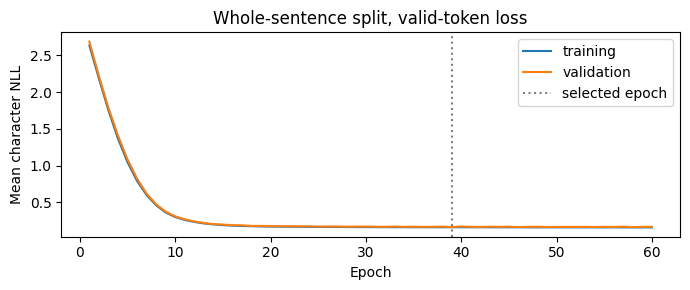

In [9]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(range(1, 61), [r[0] for r in char_history], label='training')
ax.plot(range(1, 61), [r[1] for r in char_history], label='validation')
ax.axvline(best_char_epoch, color='gray', linestyle=':', label='selected epoch')
ax.set(xlabel='Epoch', ylabel='Mean character NLL', title='Whole-sentence split, valid-token loss')
ax.legend(); fig.tight_layout(); plt.show()

### What has been completed, and what remains outside this experiment

The second project adds a sentence-level holdout, validation-selected state, token-weighted test loss, unigram/bigram comparisons, explicit special symbols, and bounded generation with recurrent state carried correctly. Assertions check split isolation, padding exclusion, incremental/full-prefix agreement, and reproducible sampling. These are local correctness checks; printed held-out results provide the predictive measurements.

The corpus is a controlled combinatorial grammar. Familiar characters and word pieces occur across splits intentionally, while exact sentences do not. It cannot establish broad language understanding or out-of-distribution performance. Loss and generation are complementary: plausible examples do not replace held-out likelihood, and low likelihood loss does not guarantee every generated sentence follows the grammar.
